# 3H - Genese: o que separa forte_p90 de super_p95?

**Pergunta especifica.** Que valores as variaveis assumem antes do onset dos eventos >P90, e o estado precursor ja separa `super_p95` de `forte_p90`?

**Objetivo.** Compostos alinhados ao ONSET e ordenamento da intensidade final usando somente as duas classes executivas da Fase 3.

**Justificativa.** A classificacao antiga foi descartada. A genese deve comparar apenas a cauda quente local: P90 versus P95.

**Metodologia.** Eventos abaixo ou iguais a P90 sao descartados. Compostos -52..+78 semanas do onset por classe (`forte_p90`, `super_p95`); estado precursor em -26/-13/0 semanas; Spearman(estado precursor -26..0, intensidade final). **Area:** caixa Nino 3.4; WWV no Pacifico equatorial.

**Saidas.** `phase3H_proveniencia_eventos.csv`, `phase3H_eventos_descartados_abaixo_p90.csv`, `phase3H_estado_precursor_por_classe.csv`, `phase3H_separacao_genese.csv` + compostos, storyline e retrato.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev_all=u.add_p90_p95_classification(u.load_events())
ev=ev_all.query('elegivel_p90_p95').copy()
desc=ev_all.query('not elegivel_p90_p95').copy()
prov=ev[['event_id','classe_p90_p95','event_start','peak_time','event_end','duration_months','peak_monthly_ssta_c','limiar_p90_c','limiar_p95_c']].copy()
prov.columns=['evento','classe','onset','pico','fim','duracao_meses','ssta_pico_c','limiar_p90_c','limiar_p95_c']
u.save_table(prov,'phase3H_proveniencia_eventos.csv',index=False)
u.save_table(desc[['event_id','peak_time','peak_monthly_ssta_c','classe_p90_p95','limiar_p90_c','limiar_p95_c']], 'phase3H_eventos_descartados_abaixo_p90.csv', index=False)
print('PROVENIENCIA - super_p95 n=%d, forte_p90 n=%d, descartados=%d'%(len(prov[prov.classe=='super_p95']),len(prov[prov.classe=='forte_p90']),len(desc)))
print(prov[['evento','classe','onset']].to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3H_proveniencia_eventos.csv
[tabela] data\processed\parquet\statistics\phase3H_eventos_descartados_abaixo_p90.csv
PROVENIENCIA - super_p95 n=6, forte_p90 n=4, descartados=2
                 evento    classe      onset
el_nino_oisst_1982_1983 super_p95 1982-07-01
el_nino_oisst_1986_1988 forte_p90 1986-10-01
el_nino_oisst_1991_1992 super_p95 1991-09-01
el_nino_oisst_1994_1995 forte_p90 1994-10-01
el_nino_oisst_1997_1998 super_p95 1997-06-01
el_nino_oisst_2002_2003 forte_p90 2002-07-01
el_nino_oisst_2006_2007 forte_p90 2006-09-01
el_nino_oisst_2009_2010 super_p95 2009-07-01
el_nino_oisst_2014_2016 super_p95 2014-10-01
el_nino_oisst_2023_2024 super_p95 2023-05-01


[figura] data\processed\figures\fase3\phase3H_compostos_onset.png


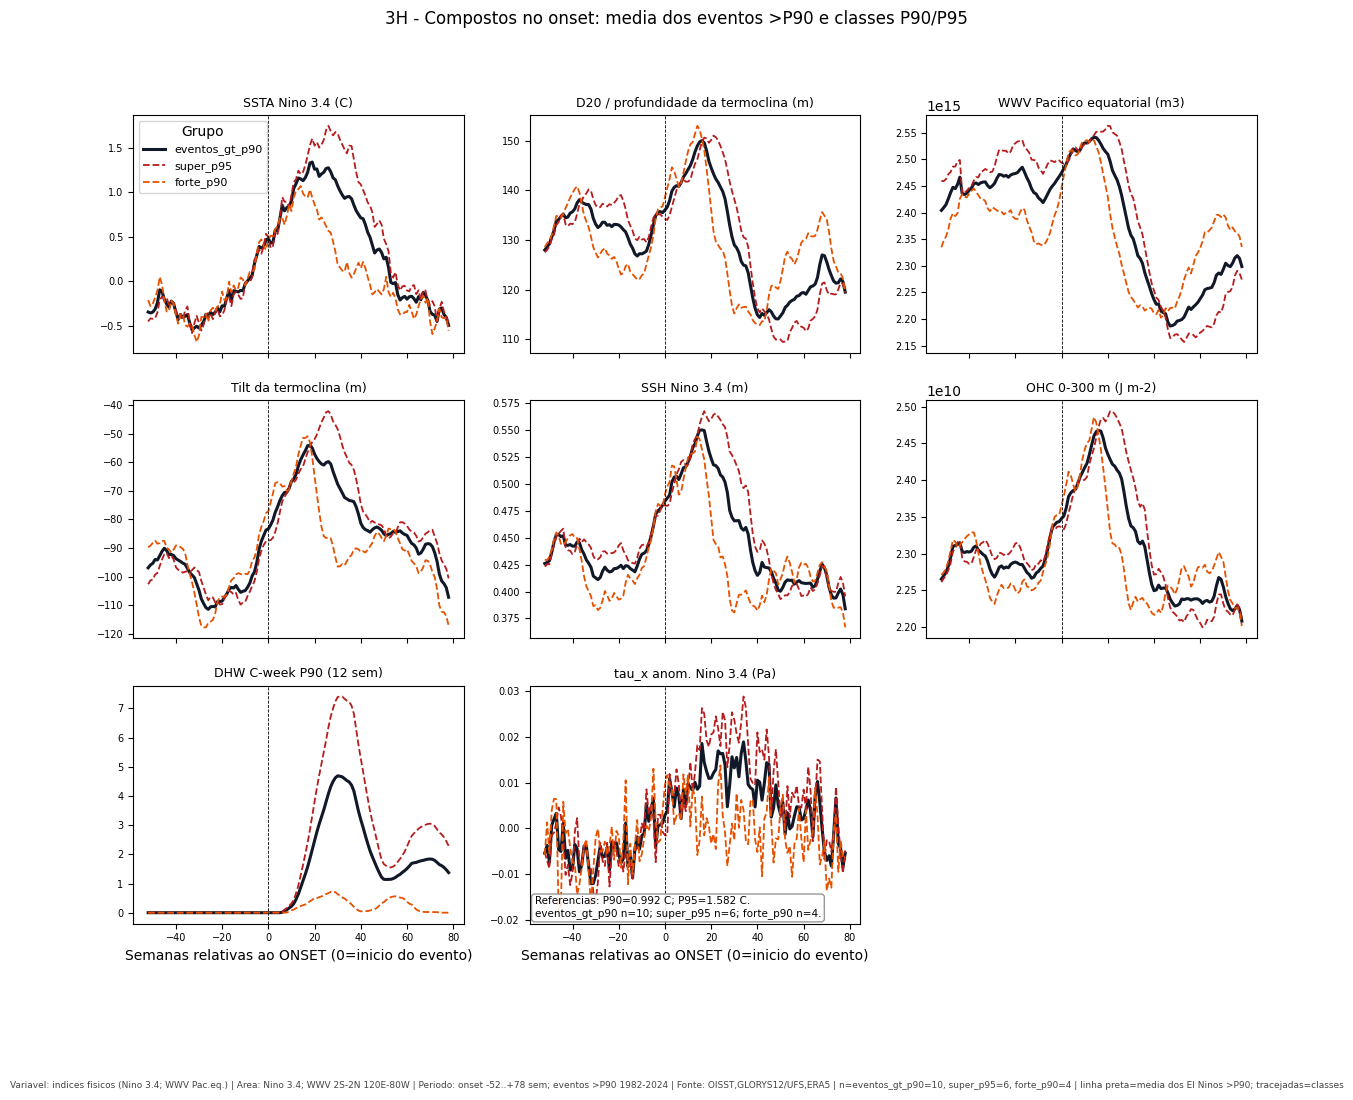

In [2]:
VARS=['nino34_ssta','d20_m','wwv','tilt_m','ssh_m','ohc_0_300','dhw_cweek_p90','tau_x_anom_nino34_pa']; LAGS=list(range(-52,79))
def onset_al(s,o):
    i=s.index.get_indexer([o],method='nearest')[0]; seg=s.iloc[max(0,i-52):i+79]
    rel=((seg.index-s.index[i]).days/7).round().astype(int); return pd.Series(seg.values,index=rel).reindex(LAGS)
groups={'eventos_gt_p90':ev}
groups.update({g:gg for g,gg in ev.groupby('classe_p90_p95')})
comps={g:pd.DataFrame({v:pd.DataFrame([onset_al(w[v],e.event_start) for _,e in gg.iterrows()]).mean() for v in VARS}) for g,gg in groups.items()}
pd.concat(comps,names=['grupo','sem_rel_onset']).to_csv(u.STATS/'phase3H_compostos_onset.csv')
fig,axes=plt.subplots(3,3,figsize=(14.5,10.5),sharex=True)
cores={'super_p95':'#b71c1c','forte_p90':'#e65100','eventos_gt_p90':'#111827'}
for ax,v in zip(axes.flat,VARS):
    for g in ['eventos_gt_p90','super_p95','forte_p90']:
        if g in comps:
            lw=2.2 if g=='eventos_gt_p90' else 1.3
            ls='-' if g=='eventos_gt_p90' else '--'
            ax.plot(LAGS,comps[g][v],color=cores[g],label=g,lw=lw,ls=ls)
    ax.axvline(0,color='k',ls='--',lw=.6); ax.set_title(u.var_label(v),fontsize=9); ax.tick_params(labelsize=7)
axes.flat[0].legend(fontsize=8,title='Grupo')
for ax in axes[-1]: ax.set_xlabel('Semanas relativas ao ONSET (0=inicio do evento)')
for ax in axes.flat[len(VARS):]: ax.axis('off')
counts=ev['classe_p90_p95'].value_counts().to_dict()
fig.suptitle('3H - Compostos no onset: media dos eventos >P90 e classes P90/P95')
u.add_note(axes.flat[-2],'Referencias: P90=%.3f C; P95=%.3f C.\neventos_gt_p90 n=%d; super_p95 n=%d; forte_p90 n=%d.'%(ev['limiar_p90_c'].iloc[0],ev['limiar_p95_c'].iloc[0],len(ev),counts.get('super_p95',0),counts.get('forte_p90',0)),loc='lower left')
u.stamp_caption(fig,variavel='indices fisicos (Nino 3.4; WWV Pac.eq.)',area='Nino 3.4; WWV 2S-2N 120E-80W',periodo='onset -52..+78 sem; eventos >P90 1982-2024',fonte='OISST,GLORYS12/UFS,ERA5',n=f"eventos_gt_p90={len(ev)}, super_p95={counts.get('super_p95',0)}, forte_p90={counts.get('forte_p90',0)}",extra='linha preta=media dos El Ninos >P90; tracejadas=classes')
u.save_fig(fig,'phase3H_compostos_onset.png'); plt.show()


[figura] data\processed\figures\fase3\phase3H_ciclo_vida.png


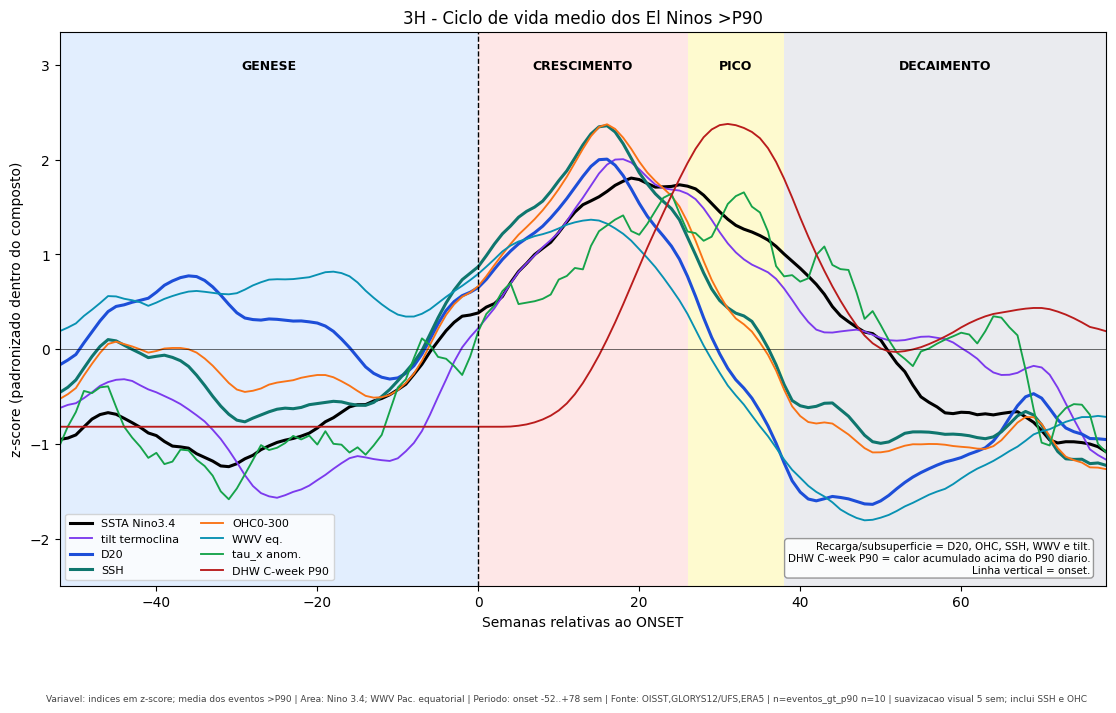

In [3]:
# storyline z-score da media dos El Ninos >P90
zc=['nino34_ssta','tilt_m','d20_m','ssh_m','ohc_0_300','wwv','tau_x_anom_nino34_pa','dhw_cweek_p90']
classe_story='eventos_gt_p90'
z=((comps[classe_story][zc]-comps[classe_story][zc].mean())/comps[classe_story][zc].std()).rolling(5,center=True,min_periods=1).mean()
fases=[(-52,0,'#dbeafe','GENESE'),(0,26,'#fee2e2','CRESCIMENTO'),(26,38,'#fef9c3','PICO'),(38,78,'#e5e7eb','DECAIMENTO')]
cores_l={'nino34_ssta':('#000','SSTA Nino3.4'),'tilt_m':('#7c3aed','tilt termoclina'),'d20_m':('#1d4ed8','D20'),'ssh_m':('#0f766e','SSH'),'ohc_0_300':('#f97316','OHC0-300'),'wwv':('#0891b2','WWV eq.'),'tau_x_anom_nino34_pa':('#16a34a','tau_x anom.'),'dhw_cweek_p90':('#b91c1c','DHW C-week P90')}
fig,ax=plt.subplots(figsize=(13.5,7.2))
for x0,x1,c,r in fases:
    ax.axvspan(x0,x1,color=c,alpha=.8,lw=0)
    ax.text((x0+x1)/2,2.95,r,ha='center',fontsize=9,weight='bold')
for v,(c,l) in cores_l.items():
    ax.plot(z.index,z[v],color=c,lw=2.2 if v in('nino34_ssta','ssh_m','d20_m') else 1.35,label=l)
ax.axvline(0,color='k',ls='--',lw=1); ax.axhline(0,color='k',lw=.4); ax.set_xlim(-52,78); ax.set_ylim(-2.5,3.35)
ax.set_xlabel('Semanas relativas ao ONSET'); ax.set_ylabel('z-score (padronizado dentro do composto)'); ax.legend(loc='lower left',fontsize=8,ncol=2)
ax.set_title('3H - Ciclo de vida medio dos El Ninos >P90')
u.add_note(ax,'Recarga/subsuperficie = D20, OHC, SSH, WWV e tilt.\nDHW C-week P90 = calor acumulado acima do P90 diario.\nLinha vertical = onset.',loc='lower right')
u.stamp_caption(fig,variavel='indices em z-score; media dos eventos >P90',area='Nino 3.4; WWV Pac. equatorial',periodo='onset -52..+78 sem',fonte='OISST,GLORYS12/UFS,ERA5',n=f"eventos_gt_p90 n={len(ev)}",extra='suavizacao visual 5 sem; inclui SSH e OHC')
u.save_fig(fig,'phase3H_ciclo_vida.png'); plt.show()


In [4]:
from scipy.stats import spearmanr
marcos=[-26,-13,0]; rows=[]
for g,gg in ev.groupby('classe_p90_p95'):
    for v in VARS:
        vals={m:[] for m in marcos}
        for _,e in gg.iterrows():
            s=onset_al(w[v],e.event_start)
            for m in marcos: vals[m].append(s.loc[m-2:m+2].mean())
        row={'classe':g,'variavel':v}
        for m in marcos:
            a=pd.Series(vals[m]).dropna(); row[f'media_{m}s']=round(a.mean(),3); row[f'range_{m}s']=f'{a.min():.2f}..{a.max():.2f}'
        rows.append(row)
u.save_table(pd.DataFrame(rows),'phase3H_estado_precursor_por_classe.csv',index=False)
rows=[]
for v in VARS:
    pre=[];it=[]
    for _,e in ev.iterrows():
        s=onset_al(w[v],e.event_start); pre.append(s.loc[-26:0].mean()); it.append(e.peak_monthly_ssta_c)
    m=pd.notna(pre); rho,p=spearmanr(pd.Series(pre)[m],pd.Series(it)[m])
    rows.append({'variavel':v,'spearman_rho':round(float(rho),3),'p_bruto':round(float(p),3),'n':int(m.sum())})
sep=pd.DataFrame(rows).sort_values('spearman_rho',key=abs,ascending=False); u.save_table(sep,'phase3H_separacao_genese.csv',index=False)
print('SEPARACAO NA GENESE (Spearman estado precursor -26..0 vs intensidade final; eventos >P90):')
for _,r in sep.iterrows(): print(f"  {r.variavel:22s} rho={r.spearman_rho:+.2f} (p={r.p_bruto:.2f})")


[tabela] data\processed\parquet\statistics\phase3H_estado_precursor_por_classe.csv
[tabela] data\processed\parquet\statistics\phase3H_separacao_genese.csv
SEPARACAO NA GENESE (Spearman estado precursor -26..0 vs intensidade final; eventos >P90):
  d20_m                  rho=+0.78 (p=0.01)
  ohc_0_300              rho=+0.65 (p=0.04)
  ssh_m                  rho=+0.49 (p=0.15)
  wwv                    rho=+0.44 (p=0.20)
  tilt_m                 rho=+0.24 (p=0.51)
  tau_x_anom_nino34_pa   rho=-0.21 (p=0.56)
  nino34_ssta            rho=+0.10 (p=0.78)
  dhw_cweek_p90          rho=+nan (p=nan)


C:\Users\thiag\AppData\Local\Temp\ipykernel_24860\3744044261.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  m=pd.notna(pre); rho,p=spearmanr(pd.Series(pre)[m],pd.Series(it)[m])


**Leitura do 3H.** A genese agora compara somente `forte_p90` e `super_p95`. Eventos abaixo ou iguais a P90 foram retirados dos compostos. A diferenca fisica continua concentrada no bloco de recarga/subsuperficie: D20/OHC/SSH/tilt aparecem antes do pico; SSTA/DHW sao mais diagnostico de fase/severidade do que causa antecipada. A leitura e descritiva, porque o n por classe e pequeno.
